## **1. Installing Required Libraries**

In [1]:
pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.7 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.1 which is incompatible.
dask-cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incompatible.
cudf-cu12 25.6.0 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.1 which is incompatible.


## **2. Importing Required Libraries**

In [15]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
# import random
import scipy
# import seaborn as sns
from scipy import signal
from skimage.transform import resize
from matplotlib.patches import FancyArrowPatch

## **3. Mounting my Google Drive**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **4. Signal Segmentation**

### **4.1 Schematic of Segmentation**

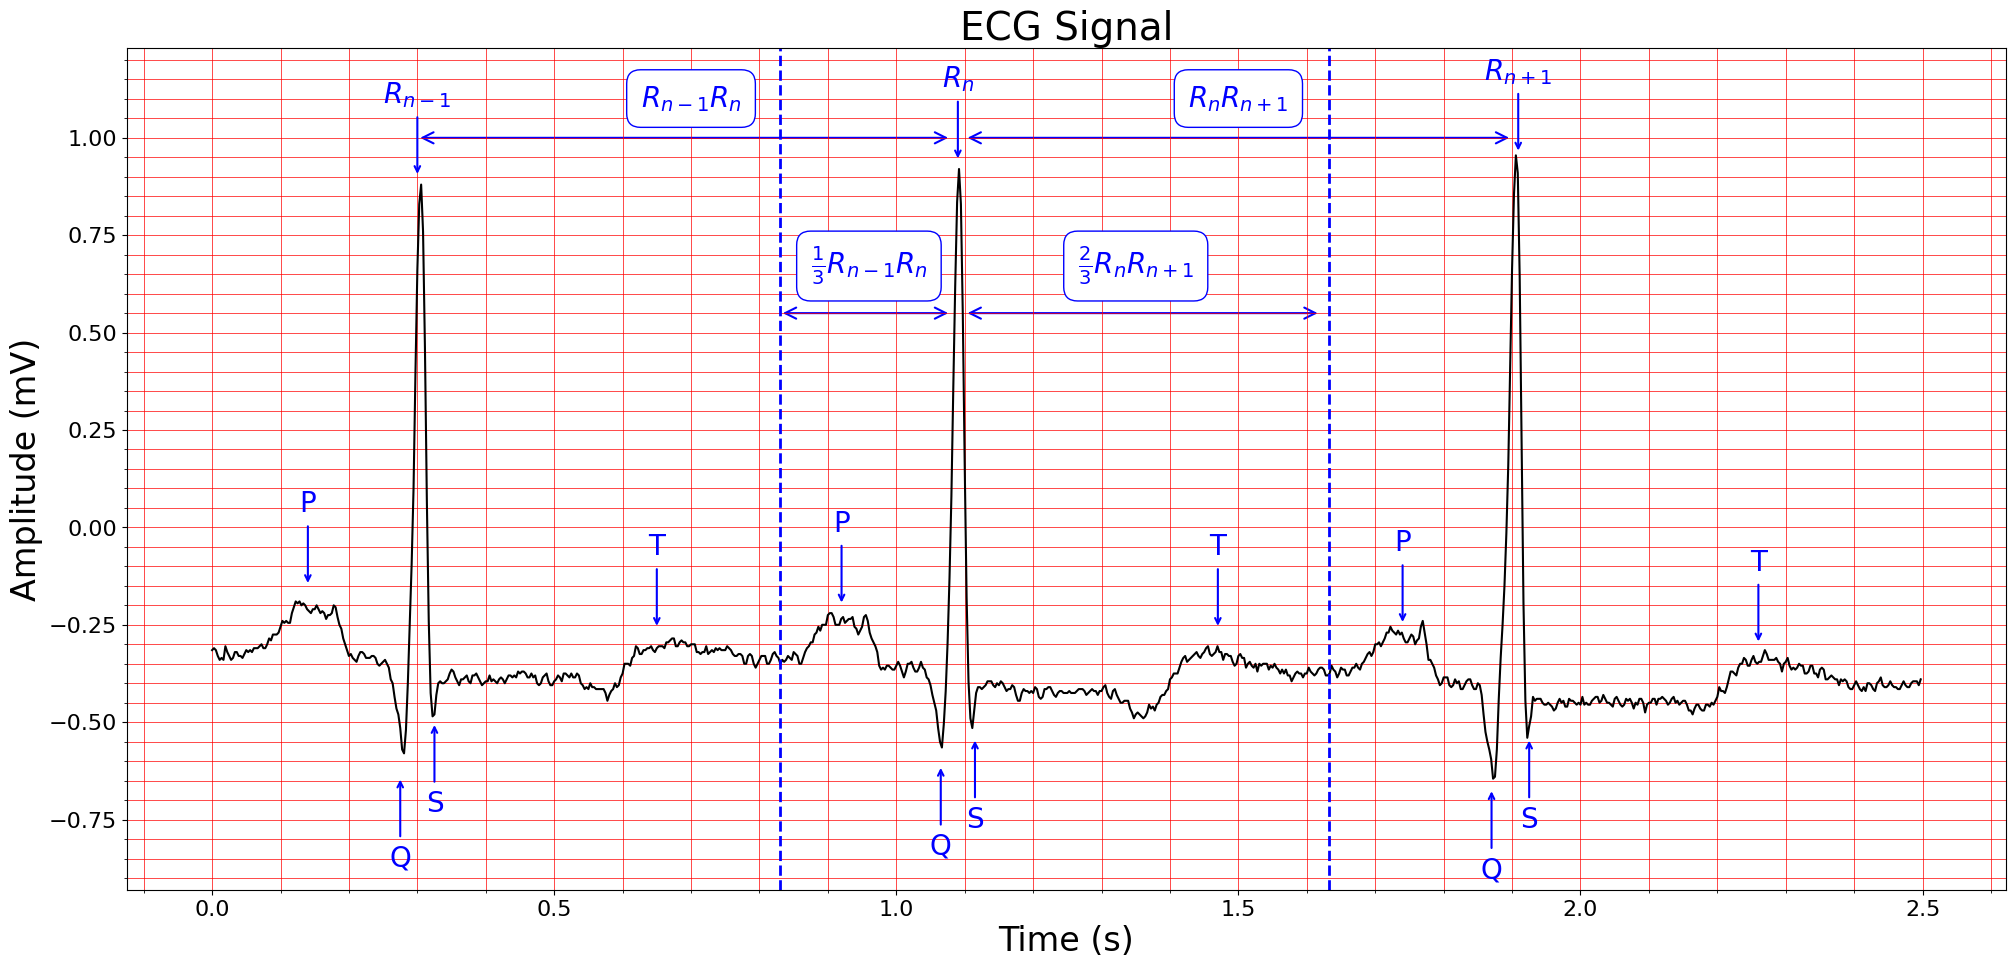

In [16]:
record_path = '/content/drive/MyDrive/Imaging Physics Group/Heart Arrhythmia Detection/mitdb/100'
start_time, end_time = 21, 23.5


signals, fields = wfdb.rdsamp(record_path)
annotation = wfdb.rdann(record_path, 'atr')

fs = fields['fs']
time = np.arange((end_time - start_time) * fs) / fs
signal = signals[int(start_time * fs):int(end_time * fs), 0]

r_peaks = np.array(annotation.sample)
r_peaks = r_peaks[(r_peaks >= int(start_time * fs)) & (r_peaks < int(end_time * fs))]
r_peaks_rel = r_peaks - int(start_time * fs)
r_peaks_time = r_peaks_rel / fs

# Plot
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(time, signal, color='black')
ax.set_title(f'ECG Signal', fontsize=28)
ax.set_xlabel('Time (s)', fontsize=24)
ax.set_ylabel('Amplitude (mV)', fontsize=24)
ax.grid(True, which='both', color='red', linestyle='-', linewidth=0.5)
ax.minorticks_on()



# Add arrows for R-peaks
lw = 1.5
font_size = 20
t, amp = 1.909, 0.96
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=lw))
plt.text(t, amp + 0.21, '$R_{n+1}$', ha='center', va='center', fontsize=font_size, color='blue')

t, amp = 1.09, 0.94
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=lw))
plt.text(t, amp + 0.21, '$R_{n}$', ha='center', va='center', fontsize=font_size, color='blue')

t, amp = 0.3, 0.9
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=lw))
plt.text(t, amp + 0.21, '$R_{n-1}$', ha='center', va='center', fontsize=font_size, color='blue')


# P-peaks
t, amp = 1.74, -0.25
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=lw))
plt.text(t, amp + 0.21, 'P', ha='center', va='center', fontsize=font_size, color='blue')


t, amp = 0.92, -0.2
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=lw))
plt.text(t, amp + 0.21, 'P', ha='center', va='center', fontsize=font_size, color='blue')

t, amp = 0.14, -0.15
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=lw))
plt.text(t, amp + 0.21, 'P', ha='center', va='center', fontsize=font_size, color='blue')


# T-peaks
t, amp = 2.26, -0.30
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=lw))
plt.text(t, amp + 0.21, 'T', ha='center', va='center', fontsize=font_size, color='blue')

t, amp = 1.47, -0.26
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=lw))
plt.text(t, amp + 0.21, 'T', ha='center', va='center', fontsize=font_size, color='blue')

t, amp = 0.65, -0.26
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='->', lw=lw))
plt.text(t, amp + 0.21, 'T', ha='center', va='center', fontsize=font_size, color='blue')


# S-peaks
t, amp = 1.925, -0.7
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='<-', lw=lw))
plt.text(t, amp - 0.05, 'S', ha='center', va='center', fontsize=font_size, color='blue')

t, amp = 1.115, -0.7
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='<-', lw=lw))
plt.text(t, amp - 0.05, 'S', ha='center', va='center', fontsize=font_size, color='blue')

t, amp = 0.325, -0.66
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='<-', lw=lw))
plt.text(t, amp - 0.05, 'S', ha='center', va='center', fontsize=font_size, color='blue')

# Q-peaks
t, amp = 1.87, -0.83
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='<-', lw=lw))
plt.text(t, amp - 0.05, 'Q', ha='center', va='center', fontsize=font_size, color='blue')

t, amp = 1.065, -0.77
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='<-', lw=lw))
plt.text(t, amp - 0.05, 'Q', ha='center', va='center', fontsize=font_size, color='blue')

t, amp = 0.275, -0.80
plt.annotate('', xy=(t, amp), xytext=(t, amp + 0.16),
             arrowprops=dict(facecolor='blue', edgecolor='blue', arrowstyle='<-', lw=lw))
plt.text(t, amp - 0.05, 'Q', ha='center', va='center', fontsize=font_size, color='blue')


# Set the beginning and end of the arrow, and the y-coordinate
x_start = 1.1
x_end = 1.9
y = 1

# Draw bi-directional arrow
ax.add_patch(FancyArrowPatch((x_start, y), (x_end, y),
                             connectionstyle="arc3,rad=0",
                             arrowstyle='<->', mutation_scale=20, lw=lw, color='blue'))

# Set the beginning and end of the arrow, and the y-coordinate
x_start = 0.3
x_end = 1.08
y = 1

# Draw bi-directional arrow
ax.add_patch(FancyArrowPatch((x_start, y), (x_end, y),
                             connectionstyle="arc3,rad=0",
                             arrowstyle='<->', mutation_scale=20, lw=lw, color='blue'))

# Set the beginning and end of the arrow, and the y-coordinate
x_start = 1.1
x_end = 1.62
y = 0.55

# Draw bi-directional arrow
ax.add_patch(FancyArrowPatch((x_start, y), (x_end, y),
                             connectionstyle="arc3,rad=0",
                             arrowstyle='<->', mutation_scale=20, lw=lw, color='blue'))

# Set the beginning and end of the arrow, and the y-coordinate
x_start = 0.83
x_end = 1.08
y = 0.55

# Draw bi-directional arrow
ax.add_patch(FancyArrowPatch((x_start, y), (x_end, y),
                             connectionstyle="arc3,rad=0",
                             arrowstyle='<->', mutation_scale=20, lw=lw, color='blue'))

x_pos, y_pos = 0.96, 0.65
plt.text(x_pos, y_pos, r'$\frac{1}{3} R_{n-1} R_{n}$', fontsize=font_size, ha='center', color='blue', bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.5'))

x_pos, y_pos = 1.35, 0.65
plt.text(x_pos, y_pos, r'$\frac{2}{3} R_{n} R_{n+1}$', fontsize=font_size, ha='center', color='blue', bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.5'))

x_pos, y_pos = 1.5, 1.08
plt.text(x_pos, y_pos, r'$R_{n} R_{n+1}$', fontsize=font_size, ha='center', color='blue', bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.5'))


x_pos, y_pos = 0.7, 1.08
plt.text(x_pos, y_pos, r'$R_{n-1} R_{n}$', fontsize=font_size, ha='center', color='blue', bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.5'))




# Add vertical lines for signal segment around 3rd peak
t2, t3, t4 = r_peaks_time  # get 2nd, 3rd, 4th peak times


# Start: third peak - 1/3 * (t3 - t2)
seg_start = t3 - (t3 - t2) / 3
# End: third peak + 2/3 * (t4 - t3)
seg_end = t3 + 2 * (t4 - t3) / 3

# Draw vertical dashed lines
ax.axvline(seg_start, color='blue', linestyle='--', linewidth=2)
ax.axvline(seg_end, color='blue', linestyle='--', linewidth=2)


plt.tight_layout()
plt.tick_params(axis='x', labelsize=16)
plt.tick_params(axis='y', labelsize=16)
plt.ylim([-0.93, 1.23])
plt.show()


### **4.2 Recording 234: Normal Strip**

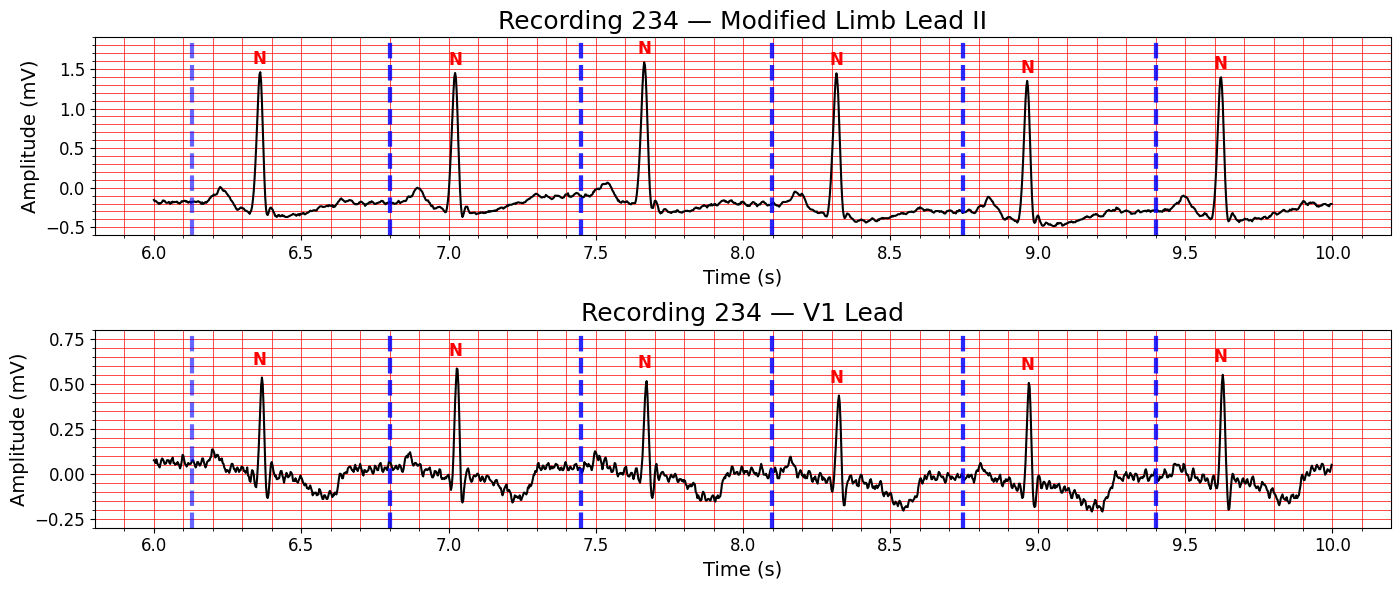

In [5]:
# Parameters
record_number = 234
record_path = f'/content/drive/MyDrive/Imaging Physics Group/Heart Arrhythmia Detection/mitdb/{record_number}'
start_time = 6
end_time = 10

# Read data
signals, fields = wfdb.rdsamp(record_path)
annotation = wfdb.rdann(record_path, 'atr')
fs = fields['fs']
sig_name = fields['sig_name']

# Get time and signal for plot window
start_idx = int(start_time * fs)
end_idx = int(end_time * fs)
time = np.arange(start_idx, end_idx) / fs

# Extract both channels
signal_ml_ii = signals[start_idx:end_idx, 0]
signal_v1 = signals[start_idx:end_idx, 1]

# R-peaks and their symbols in the full record
sample_indices = np.array(annotation.sample)
symbols = np.array(annotation.symbol)

# Define beat types to consider for R-peaks
beat_types = ['N', '.', 'L', 'R', 'e', 'j', 'V', 'E', 'A', 'S', 'J', 'a']

# Filter R-peaks and symbols to only those within the displayed time window
in_window_mask = (sample_indices >= start_idx) & (sample_indices < end_idx)
r_peaks_window = sample_indices[in_window_mask]
symbols_window = symbols[in_window_mask]

# Calculate segmentation boundaries
segment_lines = []
for i in range(1, len(sample_indices) - 1):
    if not (sample_indices[i] >= start_idx and sample_indices[i] < end_idx):
        continue
    rr_prev = sample_indices[i] - sample_indices[i - 1]
    rr_next = sample_indices[i + 1] - sample_indices[i]
    seg_start = int(sample_indices[i] - rr_prev / 3)
    seg_end = int(sample_indices[i] + (2 * rr_next) / 3)
    if seg_end < start_idx or seg_start > end_idx:
        continue
    segment_lines.append((seg_start, seg_end))

# Define time ticks for x-axis (every 0.5 seconds)
tick_interval = 0.5
time_ticks = np.arange(start_time, end_time + tick_interval, tick_interval)

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# MLII Channel plot
axes[0].plot(time, signal_ml_ii, color='black')
axes[0].set_title(f'Recording {record_number} — Modified Limb Lead II', fontsize=18)
axes[0].set_xlabel('Time (s)', fontsize=14)
axes[0].set_ylabel('Amplitude (mV)', fontsize=14)
axes[0].grid(True, which='both', axis='both', color='red', linestyle='-', linewidth=0.5)
axes[0].minorticks_on()
axes[0].set_ylim(-0.6, 1.9)
axes[0].tick_params(axis='both', which='major', labelsize=12)
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', labelbottom=True)

# V1 Channel plot
axes[1].plot(time, signal_v1, color='black')
axes[1].set_title(f'Recording {record_number} — V1 Lead', fontsize=18)
axes[1].set_xlabel('Time (s)', fontsize=14)
axes[1].set_ylabel('Amplitude (mV)', fontsize=14)
axes[1].grid(True, which='both', axis='both', color='red', linestyle='-', linewidth=0.5)
axes[1].minorticks_on()
axes[1].set_ylim(-0.3, 0.8)
axes[1].tick_params(axis='both', which='major', labelsize=12)
axes[1].set_xticks(time_ticks)

# Draw segmentation vertical lines on both plots
for seg_start, seg_end in segment_lines:
    t_start = seg_start / fs
    t_end = seg_end / fs
    if start_time <= t_start <= end_time:
        axes[0].axvline(t_start, color='b', linestyle='--', alpha=0.6, linewidth=3)
        axes[1].axvline(t_start, color='b', linestyle='--', alpha=0.6, linewidth=3)
    if start_time <= t_end <= end_time:
        axes[0].axvline(t_end, color='b', linestyle='--', alpha=0.6, linewidth=3)
        axes[1].axvline(t_end, color='b', linestyle='--', alpha=0.6, linewidth=3)

# Label each heartbeat on top of local max amplitude of that beat
window_radius = int(0.05 * fs)  # 50 ms window around R-peak to find local max amplitude

for r_peak, symbol in zip(r_peaks_window, symbols_window):
    if symbol not in beat_types:
        continue
    t_peak = r_peak / fs
    idx = r_peak - start_idx
    start_w = max(0, idx - window_radius)
    end_w = min(len(signal_ml_ii), idx + window_radius)

    if 0 <= idx < len(signal_ml_ii):
        local_max_ml_ii = np.max(signal_ml_ii[start_w:end_w])
        axes[0].text(t_peak, local_max_ml_ii + 0.05, symbol, color='red', fontsize=12,
                     ha='center', va='bottom', fontweight='bold')

    if 0 <= idx < len(signal_v1):
        local_max_v1 = np.max(signal_v1[start_w:end_w])
        axes[1].text(t_peak, local_max_v1 + 0.05, symbol, color='red', fontsize=12,
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### **4.3 Recording 233: PVC Strip**

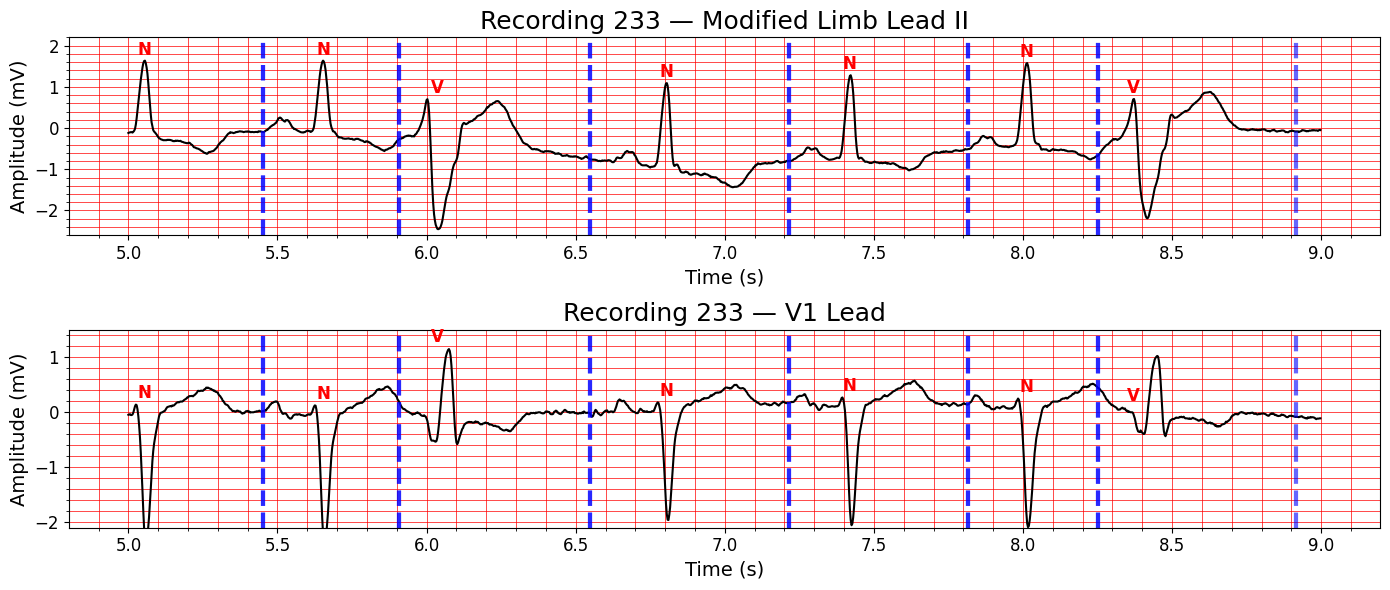

In [9]:
# Parameters
record_number = 233
record_path = f'/content/drive/MyDrive/Imaging Physics Group/Heart Arrhythmia Detection/mitdb/{record_number}'
start_time = 5
end_time = 9

# Read data
signals, fields = wfdb.rdsamp(record_path)
annotation = wfdb.rdann(record_path, 'atr')
fs = fields['fs']
sig_name = fields['sig_name']

# Get time and signal for plot window
start_idx = int(start_time * fs)
end_idx = int(end_time * fs)
time = np.arange(start_idx, end_idx) / fs

# Extract both channels
signal_ml_ii = signals[start_idx:end_idx, 0]
signal_v1 = signals[start_idx:end_idx, 1]

# R-peaks and their symbols in the full record
sample_indices = np.array(annotation.sample)
symbols = np.array(annotation.symbol)

# Define beat types to consider for R-peaks
beat_types = ['N', '.', 'L', 'R', 'e', 'j', 'V', 'E', 'A', 'S', 'J', 'a']

# Filter R-peaks and symbols to only those within the displayed time window
in_window_mask = (sample_indices >= start_idx) & (sample_indices < end_idx)
r_peaks_window = sample_indices[in_window_mask]
symbols_window = symbols[in_window_mask]

# Calculate segmentation boundaries
segment_lines = []
for i in range(1, len(sample_indices) - 1):
    if not (sample_indices[i] >= start_idx and sample_indices[i] < end_idx):
        continue
    rr_prev = sample_indices[i] - sample_indices[i - 1]
    rr_next = sample_indices[i + 1] - sample_indices[i]
    seg_start = int(sample_indices[i] - rr_prev / 3)
    seg_end = int(sample_indices[i] + (2 * rr_next) / 3)
    if seg_end < start_idx or seg_start > end_idx:
        continue
    segment_lines.append((seg_start, seg_end))

# Define time ticks for x-axis (every 0.5 seconds)
tick_interval = 0.5
time_ticks = np.arange(start_time, end_time + tick_interval, tick_interval)

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# MLII Channel plot
axes[0].plot(time, signal_ml_ii, color='black')
axes[0].set_title(f'Recording {record_number} — Modified Limb Lead II', fontsize=18)
axes[0].set_xlabel('Time (s)', fontsize=14)
axes[0].set_ylabel('Amplitude (mV)', fontsize=14)
axes[0].grid(True, which='both', axis='both', color='red', linestyle='-', linewidth=0.5)
axes[0].minorticks_on()
axes[0].set_ylim(-2.6, 2.2)
axes[0].tick_params(axis='both', which='major', labelsize=12)
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', labelbottom=True)

# V1 Channel plot
axes[1].plot(time, signal_v1, color='black')
axes[1].set_title(f'Recording {record_number} — V1 Lead', fontsize=18)
axes[1].set_xlabel('Time (s)', fontsize=14)
axes[1].set_ylabel('Amplitude (mV)', fontsize=14)
axes[1].grid(True, which='both', axis='both', color='red', linestyle='-', linewidth=0.5)
axes[1].minorticks_on()
axes[1].set_ylim(-2.1, 1.5)
axes[1].tick_params(axis='both', which='major', labelsize=12)
axes[1].set_xticks(time_ticks)

# Draw segmentation vertical lines on both plots
for seg_start, seg_end in segment_lines:
    t_start = seg_start / fs
    t_end = seg_end / fs
    if start_time <= t_start <= end_time:
        axes[0].axvline(t_start, color='b', linestyle='--', alpha=0.6, linewidth=3)
        axes[1].axvline(t_start, color='b', linestyle='--', alpha=0.6, linewidth=3)
    if start_time <= t_end <= end_time:
        axes[0].axvline(t_end, color='b', linestyle='--', alpha=0.6, linewidth=3)
        axes[1].axvline(t_end, color='b', linestyle='--', alpha=0.6, linewidth=3)

# Label each heartbeat on top of local max amplitude of that beat
window_radius = int(0.05 * fs)  # 50 ms window around R-peak to find local max amplitude

for r_peak, symbol in zip(r_peaks_window, symbols_window):
    if symbol not in beat_types:
        continue
    t_peak = r_peak / fs
    idx = r_peak - start_idx
    start_w = max(0, idx - window_radius)
    end_w = min(len(signal_ml_ii), idx + window_radius)

    if 0 <= idx < len(signal_ml_ii):
        local_max_ml_ii = np.max(signal_ml_ii[start_w:end_w])
        axes[0].text(t_peak, local_max_ml_ii + 0.05, symbol, color='red', fontsize=12,
                     ha='center', va='bottom', fontweight='bold')

    if 0 <= idx < len(signal_v1):
        local_max_v1 = np.max(signal_v1[start_w:end_w])
        axes[1].text(t_peak, local_max_v1 + 0.05, symbol, color='red', fontsize=12,
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### **4.4 Recording 233: PAC Strip**

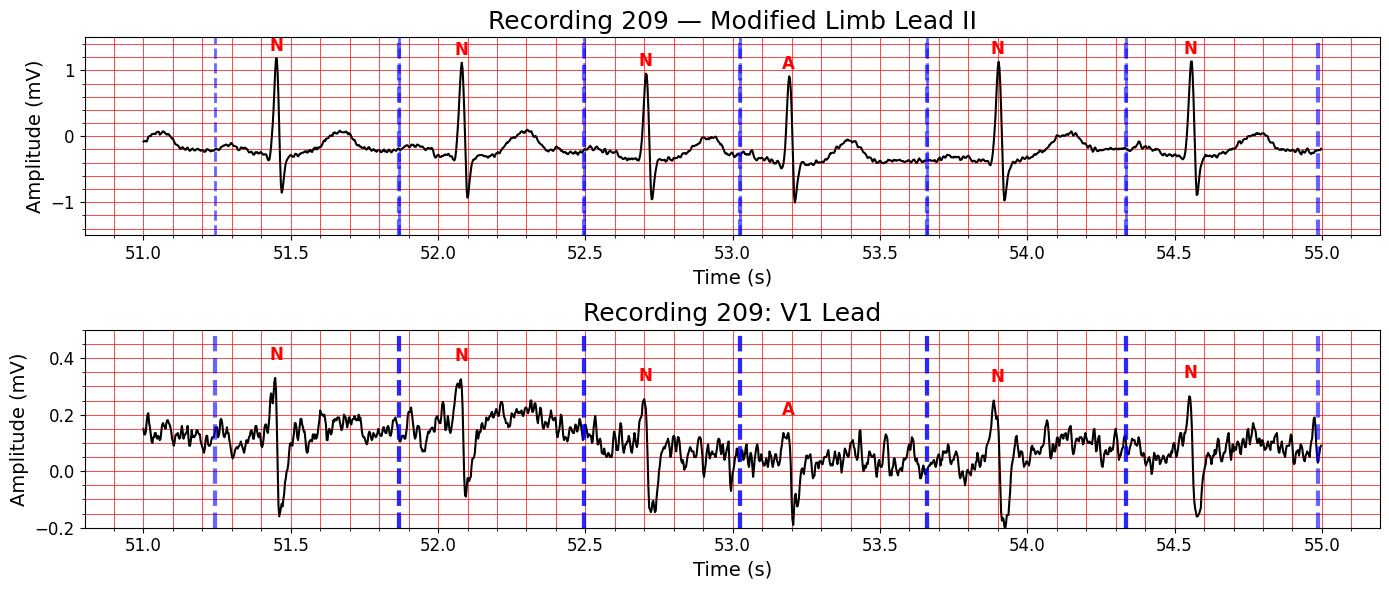

In [13]:
# Parameters
record_number = 209
record_path = f'/content/drive/MyDrive/Imaging Physics Group/Heart Arrhythmia Detection/mitdb/{record_number}'
start_time = 51
end_time = 55  # Initially 12

# Read data
signals, fields = wfdb.rdsamp(record_path)
annotation = wfdb.rdann(record_path, 'atr')
fs = fields['fs']
sig_name = fields['sig_name']

# Get time and signal for plot window
start_idx = int(start_time * fs)
end_idx = int(end_time * fs)
time = np.arange(start_idx, end_idx) / fs

# Extract both channels
signal_ml_ii = signals[start_idx:end_idx, 0]
signal_v1 = signals[start_idx:end_idx, 1]

# R-peaks and their symbols in the full record
sample_indices = np.array(annotation.sample)
symbols = np.array(annotation.symbol)

# Define beat types to consider for R-peaks
beat_types = ['N', '.', 'L', 'R', 'e', 'j', 'V', 'E', 'A', 'S', 'J', 'a']

# Filter R-peaks and symbols to only those within the displayed time window
in_window_mask = (sample_indices >= start_idx) & (sample_indices < end_idx)
r_peaks_window = sample_indices[in_window_mask]
symbols_window = symbols[in_window_mask]

# Calculate segmentation boundaries
segment_lines = []
for i in range(1, len(sample_indices) - 1):
    if not (sample_indices[i] >= start_idx and sample_indices[i] < end_idx):
        continue
    rr_prev = sample_indices[i] - sample_indices[i - 1]
    rr_next = sample_indices[i + 1] - sample_indices[i]
    seg_start = int(sample_indices[i] - rr_prev / 3)
    seg_end = int(sample_indices[i] + (2 * rr_next) / 3)
    if seg_end < start_idx or seg_start > end_idx:
        continue
    segment_lines.append((seg_start, seg_end))

# Define time ticks for x-axis (every 0.5 seconds)
tick_interval = 0.5
time_ticks = np.arange(start_time, end_time + tick_interval, tick_interval)

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# MLII Channel plot
axes[0].plot(time, signal_ml_ii, color='black')
axes[0].set_title(f'Recording {record_number} — Modified Limb Lead II', fontsize=18)
axes[0].set_xlabel('Time (s)', fontsize=14)
axes[0].set_ylabel('Amplitude (mV)', fontsize=14)
axes[0].grid(True, which='both', axis='both', color='red', linestyle='-', linewidth=0.5)
axes[0].minorticks_on()
axes[0].set_ylim(-1.5, 1.5)
axes[0].tick_params(axis='both', which='major', labelsize=12)
axes[0].set_xticks(time_ticks)
axes[0].tick_params(axis='x', labelbottom=True)

# V1 Channel plot
axes[1].plot(time, signal_v1, color='black')
axes[1].set_title(f'Recording {record_number}: V1 Lead', fontsize=18)
axes[1].set_xlabel('Time (s)', fontsize=14)
axes[1].set_ylabel('Amplitude (mV)', fontsize=14)
axes[1].grid(True, which='both', axis='both', color='red', linestyle='-', linewidth=0.5)
axes[1].minorticks_on()
axes[1].set_ylim(-0.2, 0.5)
axes[1].tick_params(axis='both', which='major', labelsize=12)
axes[1].set_xticks(time_ticks)

# Draw segmentation vertical lines on both plots
for seg_start, seg_end in segment_lines:
    t_start = seg_start / fs
    t_end = seg_end / fs
    if start_time <= t_start <= end_time:
        axes[0].axvline(t_start, color='b', linestyle='--', alpha=0.6, linewidth=2)
        axes[1].axvline(t_start, color='b', linestyle='--', alpha=0.6, linewidth=3)
    if start_time <= t_end <= end_time:
        axes[0].axvline(t_end, color='b', linestyle='--', alpha=0.6, linewidth=3)
        axes[1].axvline(t_end, color='b', linestyle='--', alpha=0.6, linewidth=3)

# Label each heartbeat on top of local max amplitude of that beat
window_radius = int(0.05 * fs)  # 50 ms window around R-peak to find local max amplitude

for r_peak, symbol in zip(r_peaks_window, symbols_window):
    if symbol not in beat_types:
        continue
    t_peak = r_peak / fs
    idx = r_peak - start_idx
    start_w = max(0, idx - window_radius)
    end_w = min(len(signal_ml_ii), idx + window_radius)

    if 0 <= idx < len(signal_ml_ii):
        local_max_ml_ii = np.max(signal_ml_ii[start_w:end_w])
        axes[0].text(t_peak, local_max_ml_ii + 0.05, symbol, color='red', fontsize=12,
                     ha='center', va='bottom', fontweight='bold')

    if 0 <= idx < len(signal_v1):
        local_max_v1 = np.max(signal_v1[start_w:end_w])
        axes[1].text(t_peak, local_max_v1 + 0.05, symbol, color='red', fontsize=12,
                     ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
